# The Random Behavior of Assets

The focus is practical: returns, drift, volatility, random walks, Wiener processes, and the continuous-time asset model.

All examples are synthetic and deterministic so the notebook is self-contained.

In [1]:
from pathlib import Path
import sys

if Path("QuantFinanceNotes/random_asset_tools").exists():
    sys.path.append("QuantFinanceNotes")

from random_asset_tools.random_behaviour import (
    TRADING_DAYS,
    annualised_estimates,
    build_convexity_example,
    create_rng,
    plot_gbm_paths,
    plot_paths,
    plot_price_path,
    plot_scaled_returns,
    plot_time_scaling,
    plot_volatility_plateau,
    plot_wiener_paths,
    rolling_annualised_volatility,
    shock_return_series,
    simulate_gbm_paths,
    simulate_many_paths,
    simulate_price_path,
    simulate_wiener_paths,
    summarise_returns,
    time_scaling_table,
)

RNG = create_rng(seed=42)

## 1. Jensen's Inequality and Convexity

Options are nonlinear payoffs. For a convex payoff function $f(S)$, randomness has value because:

$$
\mathbb{E}[f(S)] \geq f\left(\mathbb{E}[S]\right).
$$

A second-order Taylor expansion around $\bar{S}=\mathbb{E}[S]$ gives the useful intuition:

$$
\mathbb{E}[f(S)] \approx f\left(\mathbb{E}[S]\right) + \frac{1}{2} f''\left(\mathbb{E}[S]\right)\operatorname{Var}(S).
$$

The extra value comes from two ingredients: payoff convexity and variance in the underlying.


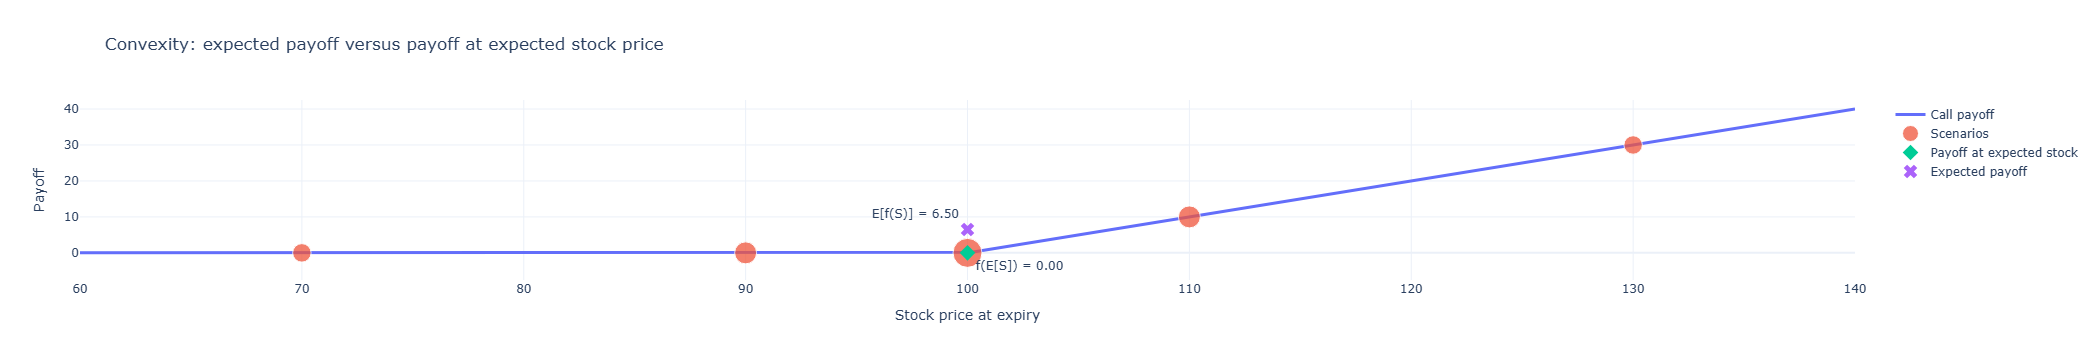

In [2]:
convexity = build_convexity_example()
convexity.figure

## 2. Returns

For an asset price series $S_i$, the simple return from time $i$ to $i+1$ is:

$$
R_i = \frac{S_{i+1} - S_i}{S_i}.
$$

Returns are more useful than absolute price changes because they scale naturally across assets with different price levels.


In [3]:
price_path = simulate_price_path(
    initial_price=100.0,
    drift=0.08,
    volatility=0.25,
    years=1.0,
    steps_per_year=TRADING_DAYS,
    rng=RNG,
)

plot_price_path(price_path)

## 3. Mean Return and Sample Standard Deviation

For $M$ observed returns, the sample mean is:

$$
\bar{R} = \frac{1}{M}\sum_{i=1}^{M} R_i.
$$

The sample standard deviation is:

$$
s_R = \sqrt{\frac{1}{M-1}\sum_{i=1}^{M}\left(R_i - \bar{R}\right)^2}.
$$

The mean is hard to estimate from short-horizon data because it scales with $\delta t$, while volatility scales with $\sqrt{\delta t}$.


In [4]:
returns = price_path["return"].dropna()
summarise_returns(returns)

,Statistic,Value
0,Mean daily return,-0.000444
1,Sample daily standard deviation,0.014766


## 4. Return Distributions

A simple model writes returns as a normally distributed random variable:

$$
R_i = \mu\delta t + \sigma\phi_i\sqrt{\delta t}, \qquad \phi_i \sim N(0,1).
$$

Standardising returns makes them comparable with the standard Normal distribution.


In [5]:
plot_scaled_returns(returns)

## 5. Drift and Volatility

With time step $\delta t$, the annualised drift estimate is:

$$
\mu = \frac{1}{M\delta t}\sum_{i=1}^{M} R_i.
$$

The annualised volatility estimate is:

$$
\sigma = \sqrt{\frac{1}{(M-1)\delta t}\sum_{i=1}^{M}\left(R_i - \bar{R}\right)^2}.
$$

In derivative pricing, volatility is usually more important than the real-world drift. Volatility dominates short horizons; drift becomes visible over long horizons.


In [6]:
annualised_estimates(returns)

,Estimate,Value
0,Annualised drift,-0.111963
1,Annualised volatility,0.234406


## 6. Discrete Random Walk

Rewriting the return model in price changes gives:

$$
S_{i+1} - S_i = \mu S_i\delta t + \sigma S_i\phi_i\sqrt{\delta t}.
$$

Equivalently:

$$
S_{i+1} = S_i\left(1 + \mu\delta t + \sigma\phi_i\sqrt{\delta t}\right).
$$

The first term is deterministic growth. The second is the random shock.


In [7]:
paths = simulate_many_paths(
    initial_price=100.0,
    drift=0.08,
    volatility=0.25,
    years=1.0,
    steps_per_year=TRADING_DAYS,
    path_count=12,
    rng=RNG,
)

plot_paths(paths, title="Discrete random-walk paths")

## 7. Time Scaling

Mean return over a small time step scales like:

$$
\text{mean} = \mu\delta t.
$$

Standard deviation scales like:

$$
\text{standard deviation} = \sigma\sqrt{\delta t}.
$$

This is why volatility is visible in daily data but drift is noisy and difficult to estimate.


In [8]:
horizons = time_scaling_table(mu=0.08, sigma=0.25)
plot_time_scaling(horizons)

## 8. Volatility Estimation and Plateauing

A moving-window volatility estimate uses recent returns only. If one unusually large return enters the window, it can create a plateau: the estimate remains elevated until that return leaves the window.

This is a measurement artefact, not necessarily persistent market risk.


In [9]:
shock_returns = shock_return_series(seed=7)
rolling_volatility = rolling_annualised_volatility(shock_returns, window=30)

plot_volatility_plateau(shock_returns, rolling_volatility)

## 9. Wiener Process

In continuous time, the random increment is written as $dX$. Informally:

$$
\mathbb{E}[dX] = 0, \qquad \mathbb{E}\left[(dX)^2\right] = dt.
$$

A discrete approximation is:

$$
dX \approx \phi\sqrt{dt}, \qquad \phi \sim N(0,1).
$$

This keeps the variance of the random increment proportional to elapsed time.


In [10]:
wiener_paths = simulate_wiener_paths(
    years=1.0,
    steps_per_year=TRADING_DAYS,
    path_count=6,
    rng=create_rng(seed=101),
)

plot_wiener_paths(wiener_paths)

## 10. Continuous-Time Asset Model

The widely used continuous-time model for equities, currencies, commodities, and indices is:

$$
dS = \mu S\,dt + \sigma S\,dX.
$$

Here:

- $\mu S\,dt$ is the deterministic drift term.
- $\sigma S\,dX$ is the stochastic volatility term.

A convenient simulation form is the geometric Brownian motion update:

$$
S_{t+\delta t} = S_t\exp\left(\left(\mu - \frac{1}{2}\sigma^2\right)\delta t + \sigma\sqrt{\delta t}\,\phi_t\right).
$$


In [11]:
gbm_paths = simulate_gbm_paths(
    initial_price=100.0,
    drift=0.08,
    volatility=0.25,
    years=2.0,
    steps_per_year=TRADING_DAYS,
    path_count=20,
    rng=create_rng(seed=202),
)

plot_gbm_paths(gbm_paths, initial_price=100.0, drift=0.08)

## Key Takeaways

- Returns, not absolute price changes, are the natural unit for comparing assets.
- Convexity makes randomness valuable for options.
- Drift scales with $\delta t$ and is hard to estimate from short samples.
- Volatility scales with $\sqrt{\delta t}$ and dominates short-horizon price movement.
- The Wiener process gives the continuous-time language for random shocks.
- The standard Chapter 3 asset model is $dS = \mu S\,dt + \sigma S\,dX$.
